# Notebook 03b — K-Means + Isolation Forest

**TFG:** Electricity Consumption Anomaly Detection and FDI Attack Mitigation in Edge Computing

---

### Hypothesis

The baseline Isolation Forest (NB03) treats the entire dataset as a single homogeneous
distribution. In reality, electricity consumption at 3:00 AM and at 7:00 PM follows
completely different distributions: a point that looks anomalous in the early morning
may be perfectly normal at peak hours. The result is **false positives driven by regime
confusion**.

Used as a **preprocessing step, K-Means** segments the samples into consumption regimes
(clusters). Within each cluster the natural variance is smaller, so genuine outliers
(FDI attacks) stand out more clearly.

### Two strategies compared

| Strategy | Description | Pros | Cons |
|---|---|---|---|
| **A: per-cluster IF** | One independent IF per cluster | Better local adaptation | Small clusters yield unstable IFs; several models to deploy |
| **B: global IF + cluster features** | A single IF with the cluster id one-hot encoded as features | Simple, robust, a single model to deploy on edge | Less specialization |

### Differences from NB03

| Aspect | NB03 (baseline) | NB03b (K-Means + IF) |
|---|---|---|
| Normalization | RobustScaler | RobustScaler + **ablation** vs MinMax vs no scaling |
| Preprocessing | None | **K-Means clustering** |
| Features | 17 (full) | 17 + K one-hot = **17 + K** |
| Model | 1 global IF | **Strategy A vs B**, selected automatically |
| Calibration | precision_recall_curve | Identical |
| Post-processing | Temporal voting | Identical |
| Comparison | — | **vs the NB03 baseline** (loads its metrics JSON) |

## 0. Setup

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.ensemble import IsolationForest

from sklearn.preprocessing import RobustScaler, MinMaxScaler

from sklearn.cluster import KMeans

from sklearn.metrics import (

    classification_report, confusion_matrix,

    roc_auc_score, roc_curve, f1_score, fbeta_score,

    precision_score, recall_score,

    average_precision_score, precision_recall_curve,

    silhouette_score

)

import joblib, time, os, json, warnings


warnings.filterwarnings('ignore')

np.random.seed(42)

plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams['figure.figsize'] = (14, 5)

plt.rcParams['font.size'] = 12

print('OK')

OK


## 1. Loading Real Data

In [2]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA_DIR = os.path.join(BASE_DIR, 'data')

with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:
    config = json.load(f)

FEATURE_COLS = config['feature_cols']
ATTACK_TYPES = config['attack_types']

df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'),
                        index_col='datetime', parse_dates=True)
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val_with_attacks.csv'),
                        index_col='datetime', parse_dates=True)
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test_with_attacks.csv'),
                        index_col='datetime', parse_dates=True)

print('DATA LOADED (real UCI)')
print('=' * 65)
for nm, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    n_atk = (d['label'] == 1).sum() if 'label' in d.columns else 0
    rng = f'{d.index.min().date()} -> {d.index.max().date()}'
    atk = f'  | {n_atk:,} attacks ({n_atk/len(d)*100:.1f}%)' if n_atk else ''
    print(f'  {nm:6s} {len(d):>10,} rows  {rng}{atk}')

DATA LOADED (real UCI)
  Train   1,300,061 rows  2006-12-16 -> 2009-06-09
  Val       144,452 rows  2009-06-09 -> 2009-09-20  | 21,739 attacks (15.0%)
  Test      604,999 rows  2009-09-20 -> 2010-11-26  | 96,717 attacks (16.0%)


## 2. Feature Engineering (mode = `full`, 17 features)

The IF receives the richest representation available, since it imposes no architectural
constraints on the number of features.

**Change v2**: the rolling features are computed over the **VI_residual** and over
**physical invariants** (GAP/I ratio, SM/GAP ratio) rather than over the attacked GAP.
Computed directly on the attacked GAP, the rolling statistics self-normalize during
sustained episodes and erase the attack signal.

**Warm-up buffer**: for val/test, the rolling features are seeded by prepending the
last 30 rows of the previous split.

In [3]:
def compute_features(df, mode='full'):
    '''
    Feature engineering with three modes, aligned with the Notebook 02 contract.
      base   (8):  7 sensors + VI_residual
      medium (13): + cyclical temporal features + gap_diff1
      full   (17): + physics-based invariant features
    '''
    f = df[FEATURE_COLS].copy()

    # VI_residual: physical inconsistency, i.e. P != V*I/1000
    f['VI_residual'] = (
        df['Global_active_power']
        - df['Voltage'] * df['Global_intensity'] / 1000.0
    )

    if mode in ('medium', 'full'):
        h = df.index.hour + df.index.minute / 60.0
        f['hour_sin'] = np.sin(2 * np.pi * h / 24)
        f['hour_cos'] = np.cos(2 * np.pi * h / 24)
        d = df.index.dayofweek
        f['dow_sin'] = np.sin(2 * np.pi * d / 7)
        f['dow_cos'] = np.cos(2 * np.pi * d / 7)
        f['gap_diff1'] = df['Global_active_power'].diff().fillna(0)

    if mode == 'full':
        f['vi_res_abs'] = f['VI_residual'].abs()
        f['vi_res_roll15_mean'] = f['vi_res_abs'].rolling(15, min_periods=1).mean()
        f['gap_intensity_ratio'] = (
            df['Global_active_power'] / (df['Global_intensity'] + 0.01)
        )
        sm_sum = df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']
        gap_wh = df['Global_active_power'] * 1000 / 60 + 1e-8
        f['sm_gap_ratio'] = np.clip(sm_sum / gap_wh, 0, 3)

    return f


# Build the features, seeding the rolling windows from a warm-up buffer
WARMUP = 30

X_train_df = compute_features(df_train, mode='full')

_val_buf = pd.concat([df_train.iloc[-WARMUP:], df_val])
_val_feat = compute_features(_val_buf, mode='full')
X_val_df  = _val_feat.iloc[WARMUP:]

_test_buf = pd.concat([df_val.iloc[-WARMUP:], df_test])
_test_feat = compute_features(_test_buf, mode='full')
X_test_df  = _test_feat.iloc[WARMUP:]

feat_names = list(X_train_df.columns)

y_val  = df_val['label'].values
y_test = df_test['label'].values

print(f'Features ({len(feat_names)}): {feat_names}')
print(f'X_train: {X_train_df.shape}  |  X_val: {X_val_df.shape}  |  X_test: {X_test_df.shape}')

Features (17): ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'gap_diff1', 'vi_res_abs', 'vi_res_roll15_mean', 'gap_intensity_ratio', 'sm_gap_ratio']
X_train: (1300061, 17)  |  X_val: (144452, 17)  |  X_test: (604999, 17)


## 3. Normalization Ablation

The IF is scale-invariant in theory (it relies on random splits), but **in practice**
features with very different ranges (Voltage ~230-250 V vs Sub_metering ~0-30 Wh)
dominate those splits. We therefore compare RobustScaler, MinMaxScaler and no
normalization.

| Scaler | Properties | Why it suits this problem |
|---|---|---|
| **RobustScaler** | Median / IQR | Robust to natural consumption outliers |
| MinMaxScaler | [0, 1] via min/max | Sensitive to extreme outliers |
| No normalization | Raw values | Baseline |

In [4]:
# Ablation: fit a lightweight IF under each scaler and compare AUC on val
scalers_to_test = {
    'RobustScaler': RobustScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'No normalization': None,
}

print('Normalization ablation (IF with 100 trees, eval on val):')
print(f'  {"Scaler":20s}  {"AUC-ROC":>8s}  {"AUC-PR":>8s}')
print('  ' + '-' * 42)

ablation_results = []
for name, sc in scalers_to_test.items():
    if sc is not None:
        X_tr = sc.fit_transform(X_train_df.values)
        X_vl = sc.transform(X_val_df.values)
    else:
        X_tr = X_train_df.values.copy()
        X_vl = X_val_df.values.copy()

    X_tr = np.nan_to_num(X_tr, nan=0.0)
    X_vl = np.nan_to_num(X_vl, nan=0.0)

    _if = IsolationForest(n_estimators=100, contamination='auto',
                          max_features=0.8, random_state=42, n_jobs=-1)
    _if.fit(X_tr)
    _scores = -_if.score_samples(X_vl)
    _auc = roc_auc_score(y_val, _scores)
    _ap  = average_precision_score(y_val, _scores)
    ablation_results.append({'Scaler': name, 'AUC-ROC': round(_auc, 4), 'AUC-PR': round(_ap, 4)})
    print(f'  {name:20s}  {_auc:>8.4f}  {_ap:>8.4f}')

print()
print('-> We select RobustScaler (robust to natural consumption outliers)')

# Selected scaler for the rest of the notebook
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_df.values)
X_val   = scaler.transform(X_val_df.values)
X_test  = scaler.transform(X_test_df.values)

X_train = np.nan_to_num(X_train, nan=0.0)
X_val   = np.nan_to_num(X_val, nan=0.0)
X_test  = np.nan_to_num(X_test, nan=0.0)

print(f'X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test.shape}')

Normalization ablation (IF with 100 trees, eval on val):
  Scaler                 AUC-ROC    AUC-PR
  ------------------------------------------
  RobustScaler            0.9148    0.6875
  MinMaxScaler            0.9148    0.6875
  No normalization        0.9148    0.6875

-> We select RobustScaler (robust to natural consumption outliers)
X_train: (1300061, 17)  |  X_val: (144452, 17)  |  X_test: (604999, 17)


## 4. K-Means Clustering over the Clean Training Set

### Objective
Segment the training samples into **consumption regimes** so that the IF has context.
We expect clusters such as:

1. **Early morning / low consumption** (~0-6 h): standby, appliances off
2. **Daytime baseline** (~7-17 h): moderate consumption
3. **Evening peak** (~18-23 h): cooking + heating/AC + lighting
4. Possibly a **weekend** regime, distinct from weekdays

### Method
- Sweep K = 2..8, using the **elbow method** (inertia) together with the **silhouette score**
- Select the K with the best silhouette automatically

Evaluating K-Means for K=2..8...
  (silhouette over subsample of 50,000)

  K=2: inertia=   438,603,819  silhouette=0.8498
  K=3: inertia=   245,985,493  silhouette=0.8524
  K=4: inertia=   204,421,502  silhouette=0.7910
  K=5: inertia=   165,672,868  silhouette=0.7970
  K=6: inertia=   130,432,828  silhouette=0.8025
  K=7: inertia=   105,694,935  silhouette=0.8146
  K=8: inertia=    93,751,269  silhouette=0.7849

-> Best K by silhouette: K=3 (score=0.8524)


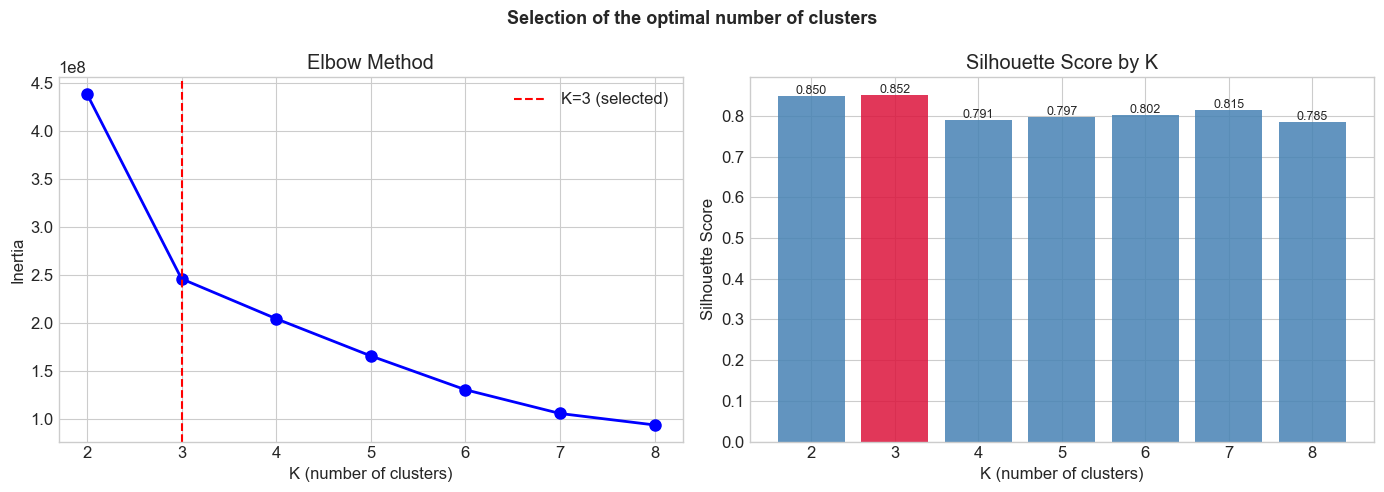

In [5]:
K_range = range(2, 9)
inertias = []
silhouettes = []

# Subsample for the silhouette score, which is O(n^2) in the number of points
n_sample = min(50_000, len(X_train))
rng_idx = np.random.RandomState(42)
sample_idx = rng_idx.choice(len(X_train), n_sample, replace=False)
X_sample = X_train[sample_idx]

print('Evaluating K-Means for K=2..8...')
print(f'  (silhouette over subsample of {n_sample:,})')
print()
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(X_train)
    inertias.append(km.inertia_)

    labels_sample = km.predict(X_sample)
    sil = silhouette_score(X_sample, labels_sample)
    silhouettes.append(sil)
    print(f'  K={k}: inertia={km.inertia_:>14,.0f}  silhouette={sil:.4f}')

# Select K automatically by best silhouette
best_k_idx = np.argmax(silhouettes)
BEST_K = list(K_range)[best_k_idx]
print(f'\n-> Best K by silhouette: K={BEST_K} (score={silhouettes[best_k_idx]:.4f})')

# Diagnostic plots: elbow curve and silhouette per K
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'bo-', lw=2, markersize=8)
axes[0].axvline(BEST_K, color='red', linestyle='--', lw=1.5,
                label=f'K={BEST_K} (selected)')
axes[0].set(xlabel='K (number of clusters)', ylabel='Inertia',
            title='Elbow Method')
axes[0].legend()

colors = ['steelblue'] * len(list(K_range))
colors[best_k_idx] = 'crimson'
axes[1].bar(list(K_range), silhouettes, color=colors, alpha=0.85)
axes[1].set(xlabel='K (number of clusters)', ylabel='Silhouette Score',
            title='Silhouette Score by K')
for i, (k, s) in enumerate(zip(K_range, silhouettes)):
    axes[1].text(k, s + 0.005, f'{s:.3f}', ha='center', fontsize=9)

plt.suptitle('Selection of the optimal number of clusters',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Final K-Means: Training and Cluster Analysis

We fit K-Means with the chosen K and examine what each cluster represents.

Cluster distribution in train (K=3):
  Cluster 0:   32,127 samples (2.5%)
  Cluster 1: 1,237,727 samples (95.2%)
  Cluster 2:   30,207 samples (2.3%)


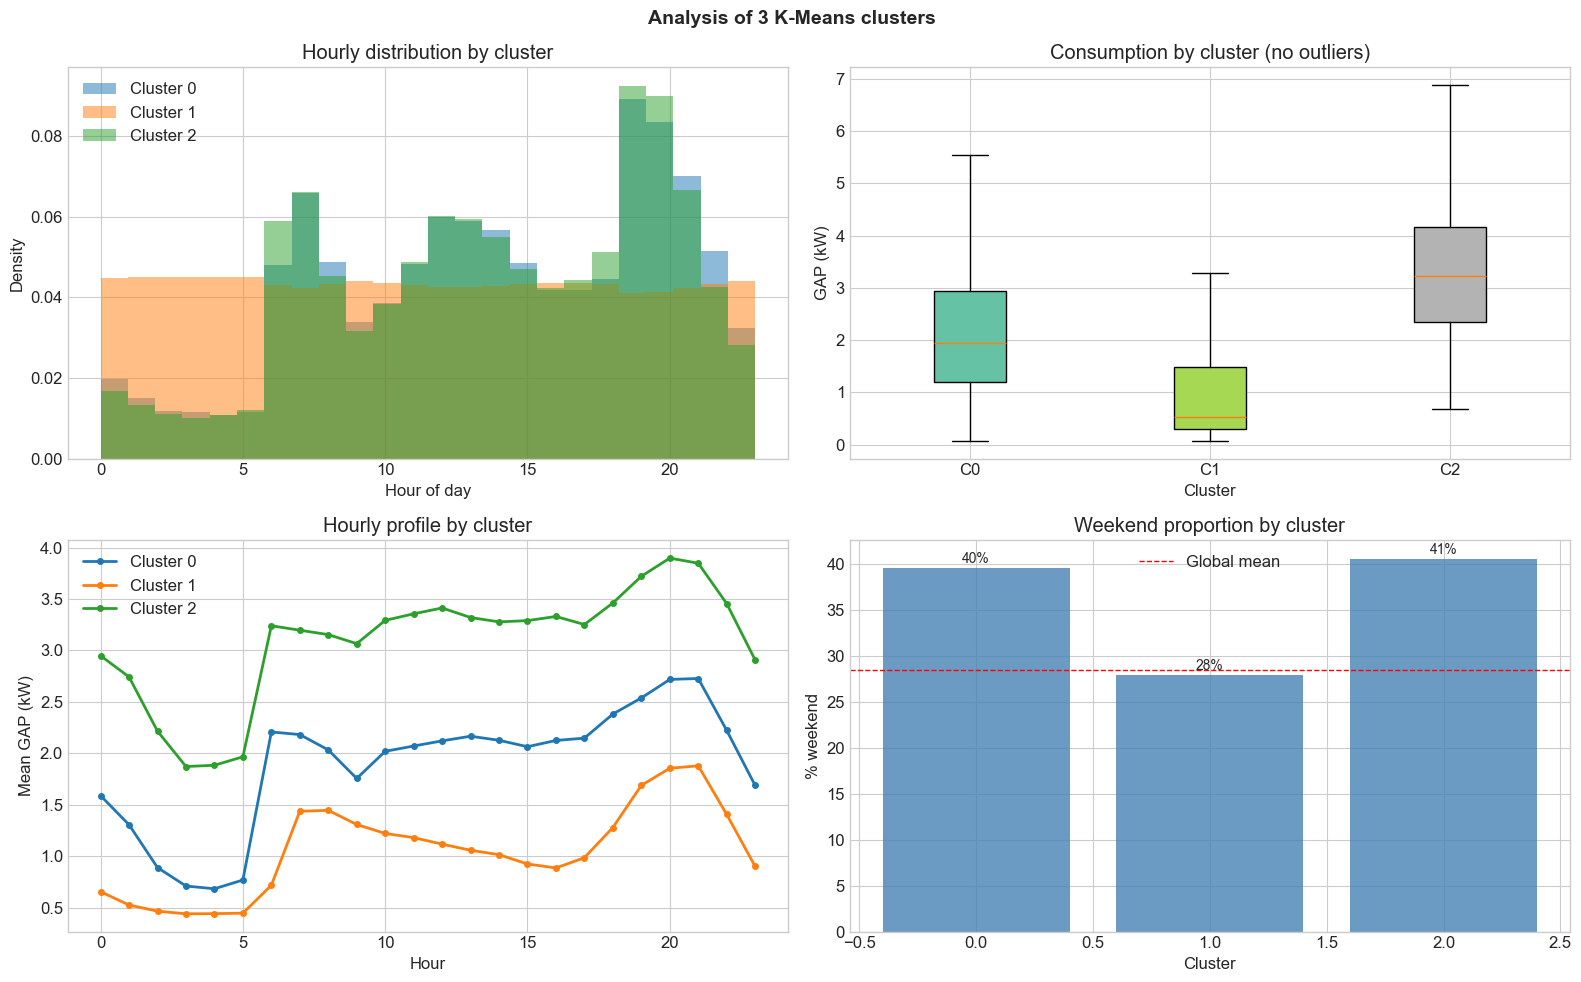


Summary by cluster:
   Cluster   Mean hour    Mean GAP  % Wknd         N
  --------------------------------------------------
         0        13.8h      2.154 kW     40%    32,127
         1        11.4h      1.044 kW     28%  1,237,727
         2        13.8h      3.343 kW     41%    30,207


In [6]:
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10, max_iter=300)
kmeans.fit(X_train)

cluster_train = kmeans.predict(X_train)
cluster_val   = kmeans.predict(X_val)
cluster_test  = kmeans.predict(X_test)

print(f'Cluster distribution in train (K={BEST_K}):')
for c in range(BEST_K):
    n = (cluster_train == c).sum()
    print(f'  Cluster {c}: {n:>8,} samples ({n/len(cluster_train)*100:.1f}%)')

# Characterize each cluster against time-of-day and weekday/weekend
df_analysis = df_train.copy()
df_analysis['cluster'] = cluster_train
df_analysis['hour'] = df_analysis.index.hour
df_analysis['is_weekend'] = df_analysis.index.dayofweek >= 5

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Distribution over hour of day, per cluster
for c in range(BEST_K):
    mask = df_analysis['cluster'] == c
    axes[0, 0].hist(df_analysis.loc[mask, 'hour'], bins=24, alpha=0.5,
                     label=f'Cluster {c}', density=True)
axes[0, 0].set(xlabel='Hour of day', ylabel='Density',
                title='Hourly distribution by cluster')
axes[0, 0].legend()

# 2. Consumption per cluster (boxplot)
data_for_box = [df_analysis.loc[df_analysis['cluster'] == c,
                'Global_active_power'].values for c in range(BEST_K)]
bp = axes[0, 1].boxplot(data_for_box, labels=[f'C{c}' for c in range(BEST_K)],
                         patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'],
                         plt.cm.Set2(np.linspace(0, 1, BEST_K))):
    patch.set_facecolor(color)
axes[0, 1].set(xlabel='Cluster', ylabel='GAP (kW)',
                title='Consumption by cluster (no outliers)')

# 3. Mean consumption profile across the day
for c in range(BEST_K):
    mask = df_analysis['cluster'] == c
    hourly = df_analysis.loc[mask].groupby('hour')['Global_active_power'].mean()
    axes[1, 0].plot(hourly.index, hourly.values, 'o-', label=f'Cluster {c}',
                     lw=2, markersize=4)
axes[1, 0].set(xlabel='Hour', ylabel='Mean GAP (kW)',
                title='Hourly profile by cluster')
axes[1, 0].legend()

# 4. Share of weekend samples per cluster
we_pct = [df_analysis.loc[df_analysis['cluster'] == c, 'is_weekend'].mean() * 100
           for c in range(BEST_K)]
bars = axes[1, 1].bar(range(BEST_K), we_pct, color='steelblue', alpha=0.8)
axes[1, 1].axhline(df_analysis['is_weekend'].mean() * 100,
                     color='red', linestyle='--', lw=1, label='Global mean')
axes[1, 1].set(xlabel='Cluster', ylabel='% weekend',
                title='Weekend proportion by cluster')
axes[1, 1].legend()
for bar, pct in zip(bars, we_pct):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{pct:.0f}%', ha='center', fontsize=10)

plt.suptitle(f'Analysis of {BEST_K} K-Means clusters',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Per-cluster summary table
print('\nSummary by cluster:')
print(f'  {"Cluster":>8s}  {"Mean hour":>10s}  {"Mean GAP":>10s}  {"% Wknd":>6s}  {"N":>8s}')
print('  ' + '-' * 50)
for c in range(BEST_K):
    sub = df_analysis[df_analysis['cluster'] == c]
    print(f'  {c:>8d}  {sub["hour"].mean():>10.1f}h  '
          f'{sub["Global_active_power"].mean():>9.3f} kW  '
          f'{sub["is_weekend"].mean()*100:>5.0f}%  '
          f'{len(sub):>8,}')

## 6. Cluster Features (One-Hot Encoding)

We encode the cluster id as **one-hot** rather than ordinal, so the IF does not infer
a spurious ordering between clusters.

```
Total features = 17 base + K one-hot = 17 + K
```

In [7]:
def add_cluster_onehot(X, cluster_labels, n_clusters):
    '''Append the one-hot cluster_id columns to the feature matrix.'''
    onehot = np.zeros((len(cluster_labels), n_clusters), dtype=np.float64)
    for i, c in enumerate(cluster_labels):
        onehot[i, c] = 1.0
    return np.hstack([X, onehot])

X_train_aug = add_cluster_onehot(X_train, cluster_train, BEST_K)
X_val_aug   = add_cluster_onehot(X_val,   cluster_val,   BEST_K)
X_test_aug  = add_cluster_onehot(X_test,  cluster_test,  BEST_K)

feat_names_aug = feat_names + [f'cluster_{i}' for i in range(BEST_K)]

print(f'Base features:      {len(feat_names)}')
print(f'Clusters (one-hot): {BEST_K}')
print(f'Total features:     {len(feat_names_aug)}')
print()
print(f'X_train_aug: {X_train_aug.shape}')
print(f'X_val_aug:   {X_val_aug.shape}')
print(f'X_test_aug:  {X_test_aug.shape}')

Base features:      17
Clusters (one-hot): 3
Total features:     20

X_train_aug: (1300061, 20)
X_val_aug:   (144452, 20)
X_test_aug:  (604999, 20)


## 7. Strategy A: One Isolation Forest per Cluster

An independent Isolation Forest trained **only on the data belonging to its cluster**.

- **Advantage**: each IF specializes in its own consumption regime
- **Drawback**: small clusters mean little data and unstable IFs, and K separate
  models must be managed on edge

In [8]:
print('STRATEGY A: IF per cluster')
print('=' * 60)

models_per_cluster = {}
t0 = time.time()

for c in range(BEST_K):
    mask_c = (cluster_train == c)
    X_c = X_train[mask_c]  # 17 base features, restricted to this cluster

    if_c = IsolationForest(
        n_estimators=300, contamination='auto',
        max_features=0.8, random_state=42, n_jobs=-1
    )
    if_c.fit(X_c)
    models_per_cluster[c] = if_c
    print(f'  Cluster {c}: {mask_c.sum():>8,} samples, '
          f'offset={if_c.offset_:.4f}')

t_train_A = time.time() - t0
print(f'\nTotal training: {t_train_A:.2f} s')

# Scoring: route each sample to the IF of its assigned cluster
def score_per_cluster(X_scaled, cluster_labels, models):
    '''Score each sample with the IF of its assigned cluster.'''
    scores = np.zeros(len(X_scaled))
    for c, model in models.items():
        mask = (cluster_labels == c)
        if mask.any():
            scores[mask] = -model.score_samples(X_scaled[mask])
    return scores

scores_val_A  = score_per_cluster(X_val,  cluster_val,  models_per_cluster)
scores_test_A = score_per_cluster(X_test, cluster_test, models_per_cluster)

auc_val_A = roc_auc_score(y_val, scores_val_A)
ap_val_A  = average_precision_score(y_val, scores_val_A)
print(f'\nVal:  AUC-ROC={auc_val_A:.4f}  AUC-PR={ap_val_A:.4f}')

STRATEGY A: IF per cluster
  Cluster 0:   32,127 samples, offset=-0.5000
  Cluster 1: 1,237,727 samples, offset=-0.5000
  Cluster 2:   30,207 samples, offset=-0.5000

Total training: 10.23 s

Val:  AUC-ROC=0.9224  AUC-PR=0.7613


## 8. Strategy B: Global Isolation Forest with Cluster Features

A single Isolation Forest that receives the 17 base features plus the K cluster
one-hot columns. The IF can then learn internally that different clusters have
different normal distributions.

- **Advantage**: a single model, which keeps edge deployment simple
- **Advantage**: the IF can combine information from the base features and the cluster id

In [9]:
print('STRATEGY B: global IF + cluster features')
print('=' * 60)

t0 = time.time()

model_if_B = IsolationForest(
    n_estimators=300,
    contamination='auto',
    max_features=0.8,
    max_samples='auto',
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)
model_if_B.fit(X_train_aug)

t_train_B = time.time() - t0
print(f'Training: {t_train_B:.2f} s')
print(f'  n_features:   {model_if_B.n_features_in_} (17 base + {BEST_K} cluster)')
print(f'  max_samples:  {model_if_B.max_samples_:,}')
print(f'  offset:       {model_if_B.offset_:.4f}')

scores_val_B  = -model_if_B.score_samples(X_val_aug)
scores_test_B = -model_if_B.score_samples(X_test_aug)

auc_val_B = roc_auc_score(y_val, scores_val_B)
ap_val_B  = average_precision_score(y_val, scores_val_B)
print(f'\nVal:  AUC-ROC={auc_val_B:.4f}  AUC-PR={ap_val_B:.4f}')

STRATEGY B: global IF + cluster features
Training: 20.60 s
  n_features:   20 (17 base + 3 cluster)
  max_samples:  256
  offset:       -0.5000

Val:  AUC-ROC=0.9085  AUC-PR=0.6293


## 9. Comparison A vs B and Automatic Selection

We pick the strategy with the higher **AUC-PR** on validation (AUC-PR is more
informative than AUC-ROC under class imbalance).

In [10]:
print('COMPARISON - STRATEGY A vs B (Validation Set)')
print('=' * 65)
print(f'  {"Strategy":35s} {"AUC-ROC":>8s}  {"AUC-PR":>8s}  {"Train":>7s}')
print('  ' + '-' * 63)
print(f'  {"A: IF per cluster":35s} {auc_val_A:>8.4f}  {ap_val_A:>8.4f}  {t_train_A:>6.1f}s')
print(f'  {"B: global IF + cluster features":35s} {auc_val_B:>8.4f}  {ap_val_B:>8.4f}  {t_train_B:>6.1f}s')

# Selection by AUC-PR
if ap_val_B >= ap_val_A:
    STRATEGY = 'B'
    scores_val  = scores_val_B
    scores_test = scores_test_B
    t_train = t_train_B
    print(f'\n-> Winner: Strategy B (AUC-PR={ap_val_B:.4f})')
    print(f'   Edge advantage: a single model, {model_if_B.n_features_in_} features')
else:
    STRATEGY = 'A'
    scores_val  = scores_val_A
    scores_test = scores_test_A
    t_train = t_train_A
    print(f'\n-> Winner: Strategy A (AUC-PR={ap_val_A:.4f})')
    print(f'   Note: requires {BEST_K} IF models on edge')

COMPARISON - STRATEGY A vs B (Validation Set)
  Strategy                             AUC-ROC    AUC-PR    Train
  ---------------------------------------------------------------
  A: IF per cluster                     0.9224    0.7613    10.2s
  B: global IF + cluster features       0.9085    0.6293    20.6s

-> Winner: Strategy A (AUC-PR=0.7613)
   Note: requires 3 IF models on edge


## 10. Threshold Calibration on the Validation Set

As in NB03, `precision_recall_curve` evaluates **every** candidate threshold. We
optimize F1 and also report F2, which weighs recall twice as heavily and is therefore
better suited to a security setting.

In [11]:
def calibrate_threshold(y_true, scores, beta=1.0):
    '''
    Find the threshold that maximizes F_beta across every candidate threshold.
    Built on sklearn's precision_recall_curve (O(n log n), no fixed grid).
    '''
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    precisions = precisions[:-1]
    recalls    = recalls[:-1]

    fbeta = ((1 + beta**2) * precisions * recalls /
             (beta**2 * precisions + recalls + 1e-10))

    best_idx = np.argmax(fbeta)
    best_thr = thresholds[best_idx]

    n = len(thresholds)
    if n > 500:
        idx = np.linspace(0, n-1, 500, dtype=int)
    else:
        idx = np.arange(n)

    results_df = pd.DataFrame({
        'threshold':  thresholds[idx],
        'precision':  precisions[idx],
        'recall':     recalls[idx],
        'f1':         ((2 * precisions * recalls) / (precisions + recalls + 1e-10))[idx],
        'f2':         ((5 * precisions * recalls) / (4 * precisions + recalls + 1e-10))[idx],
    })

    return best_thr, fbeta[best_idx], results_df


best_thr, best_f1, cal_df = calibrate_threshold(y_val, scores_val, beta=1.0)
_, best_f2, _ = calibrate_threshold(y_val, scores_val, beta=2.0)

print(f'Optimal threshold (val, F1): {best_thr:.6f}')
print(f'  F1 on val: {best_f1:.4f}')
print(f'  F2 on val: {best_f2:.4f}')

Optimal threshold (val, F1): 0.559491
  F1 on val: 0.7175
  F2 on val: 0.7693


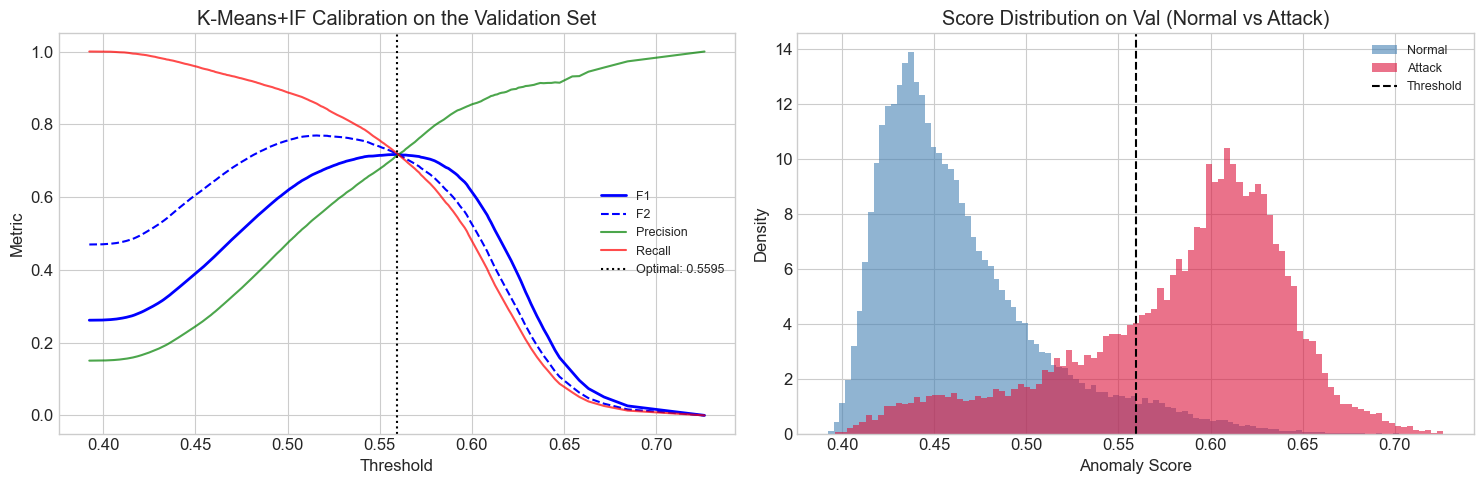

In [12]:
# Calibration curves and the val score distribution (normal vs attack)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(cal_df['threshold'], cal_df['f1'], 'b-', lw=2, label='F1')
ax.plot(cal_df['threshold'], cal_df['f2'], 'b--', lw=1.5, label='F2')
ax.plot(cal_df['threshold'], cal_df['precision'], 'g-', lw=1.5,
        label='Precision', alpha=0.7)
ax.plot(cal_df['threshold'], cal_df['recall'], 'r-', lw=1.5,
        label='Recall', alpha=0.7)
ax.axvline(best_thr, color='k', linestyle=':', lw=1.5,
           label=f'Optimal: {best_thr:.4f}')
ax.set(xlabel='Threshold', ylabel='Metric',
       title='K-Means+IF Calibration on the Validation Set')
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(scores_val[y_val == 0], bins=100, alpha=0.6, color='steelblue',
        label='Normal', density=True)
ax.hist(scores_val[y_val == 1], bins=100, alpha=0.6, color='crimson',
        label='Attack', density=True)
ax.axvline(best_thr, color='k', linestyle='--', lw=1.5, label='Threshold')
ax.set(xlabel='Anomaly Score', ylabel='Density',
       title='Score Distribution on Val (Normal vs Attack)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 11. Raw Evaluation (no post-processing)

Point-by-point metrics, measured before the temporal voting filter is applied.

In [13]:
y_pred = (scores_test > best_thr).astype(int)

print('=' * 60)
print(f'METRICS - K-MEANS+IF (Strategy {STRATEGY}, RAW)')
print('=' * 60)
print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

f1   = f1_score(y_test, y_pred)
f2   = fbeta_score(y_test, y_pred, beta=2)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, scores_test)
auc_pr  = average_precision_score(y_test, scores_test)

print(f'AUC-ROC: {auc_roc:.4f}  |  AUC-PR: {auc_pr:.4f}')
print(f'F1: {f1:.4f}  |  F2: {f2:.4f}  |  Precision: {prec:.4f}  |  Recall: {rec:.4f}')

METRICS - K-MEANS+IF (Strategy A, RAW)

              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95    508282
      Attack       0.75      0.76      0.76     96717

    accuracy                           0.92    604999
   macro avg       0.85      0.86      0.85    604999
weighted avg       0.92      0.92      0.92    604999



AUC-ROC: 0.9270  |  AUC-PR: 0.7644
F1: 0.7563  |  F2: 0.7586  |  Precision: 0.7525  |  Recall: 0.7601


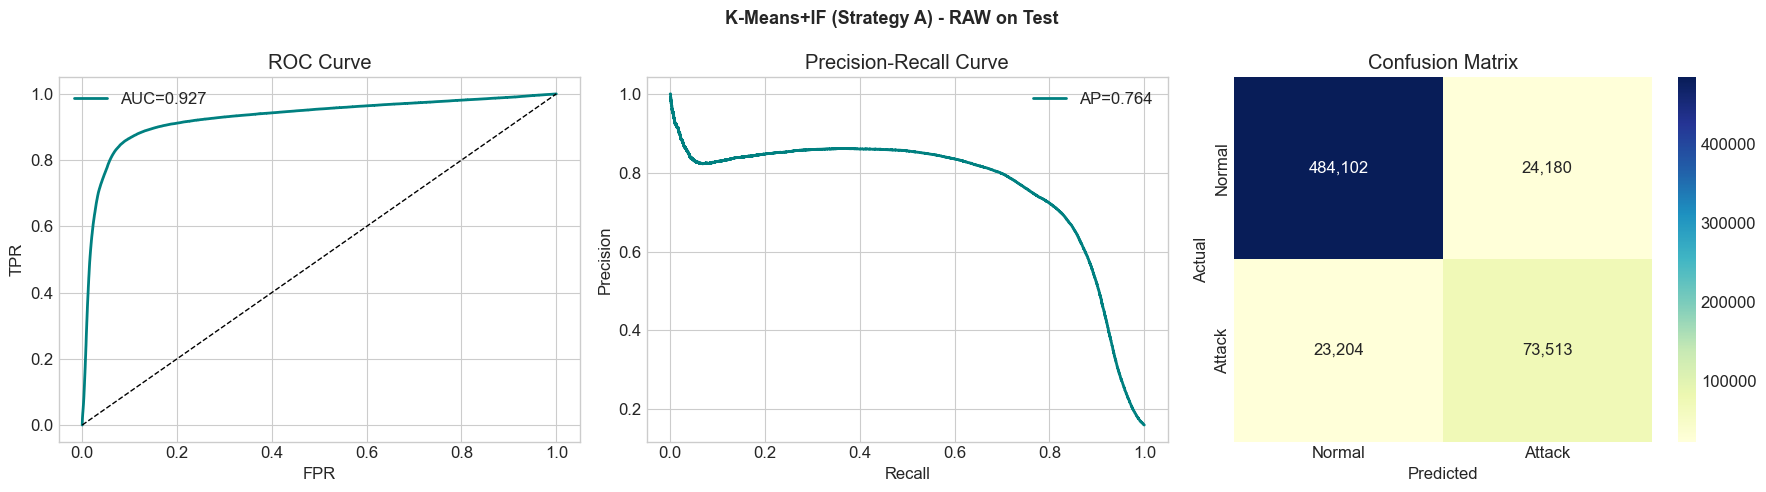

In [14]:
# ROC + PR + Confusion Matrix (RAW)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_test, scores_test)
axes[0].plot(fpr, tpr, 'teal', lw=2, label=f'AUC={auc_roc:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
axes[0].legend()

pr_c, rc_c, _ = precision_recall_curve(y_test, scores_test)
axes[1].plot(rc_c, pr_c, 'teal', lw=2, label=f'AP={auc_pr:.3f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
axes[1].legend()

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='YlGnBu',
            ax=axes[2], xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
axes[2].set(xlabel='Predicted', ylabel='Actual', title='Confusion Matrix')

plt.suptitle(f'K-Means+IF (Strategy {STRATEGY}) - RAW on Test',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Temporal Post-processing — Voting Filter

As in NB03. We exploit the fact that natural false positives are isolated points
(1-3 min), whereas the true positives of FDI attacks form sustained episodes
(15-120 min).

At each minute `t`, we raise an alarm if at least K of the last W predictions are positive.

In [15]:
def temporal_vote_vectorized(y_pred, W, K):
    '''
    Vectorized causal voting filter.
    At each t, raise an alarm if at least K of the last W predictions are positive.
    Implemented with a cumulative sum, so it runs in O(n).
    '''
    cum = np.concatenate([[0], np.cumsum(y_pred)])
    n = len(y_pred)
    ends = np.arange(1, n + 1)
    starts = np.maximum(0, ends - W)
    votes = cum[ends] - cum[starts]
    return (votes >= K).astype(int)


# Grid search over (W, K) on the validation set
y_pred_val_raw = (scores_val > best_thr).astype(int)

print(f'Raw predictions on val: {y_pred_val_raw.sum():,} positives '
      f'({y_pred_val_raw.mean()*100:.1f}%)')
print()

W_candidates = [3, 5, 7, 9, 11, 15, 21, 30]
best_wk_f1, best_W, best_K = 0, 3, 2
grid_results = []

for W in W_candidates:
    for K in range(2, W + 1):
        y_sm = temporal_vote_vectorized(y_pred_val_raw, W, K)
        f1_sm = f1_score(y_val, y_sm)
        pr_sm = precision_score(y_val, y_sm, zero_division=0)
        rc_sm = recall_score(y_val, y_sm)
        f2_sm = fbeta_score(y_val, y_sm, beta=2)
        grid_results.append({
            'W': W, 'K': K, 'f1': f1_sm, 'f2': f2_sm,
            'precision': pr_sm, 'recall': rc_sm,
            'n_pos': y_sm.sum()
        })
        if f1_sm > best_wk_f1:
            best_wk_f1, best_W, best_K = f1_sm, W, K

grid_df = pd.DataFrame(grid_results)

print(f'Best (W, K) on val: W={best_W}, K={best_K}')
best_row = grid_df.loc[grid_df['f1'].idxmax()]
print(f'  F1:        {best_row["f1"]:.4f}')
print(f'  F2:        {best_row["f2"]:.4f}')
print(f'  Precision: {best_row["precision"]:.4f}')
print(f'  Recall:    {best_row["recall"]:.4f}')
print()

f1_raw_val  = f1_score(y_val, y_pred_val_raw)
pr_raw_val  = precision_score(y_val, y_pred_val_raw, zero_division=0)
rc_raw_val  = recall_score(y_val, y_pred_val_raw)
print(f'Val RAW:      F1={f1_raw_val:.4f}  P={pr_raw_val:.4f}  R={rc_raw_val:.4f}')
print(f'Val SMOOTHED: F1={best_wk_f1:.4f}  P={best_row["precision"]:.4f}  R={best_row["recall"]:.4f}')
delta_f1 = best_wk_f1 - f1_raw_val
print(f'  F1 improvement: +{delta_f1:.4f} ({delta_f1/(f1_raw_val+1e-10)*100:+.0f}%)')


# -- LEVER A: joint search over (threshold x W x K) on val --
prc_pr_, prc_rc_, prc_thr_ = precision_recall_curve(y_val, scores_val)
prc_thr_ = prc_thr_[prc_thr_ > 0]
if len(prc_thr_) < 5:
    thr_candidates = np.linspace(scores_val.min(), scores_val.max(), 40)
else:
    thr_candidates = np.unique(np.quantile(prc_thr_, np.linspace(0.30, 0.999, 80)))
W_grid_joint = [3, 5, 7, 9, 11, 15, 21, 31, 45, 60]
best_joint_f1 = -1.0
best_joint = (best_thr, best_W, best_K)
for thr in thr_candidates:
    preds_v = (scores_val > thr).astype(int)
    if preds_v.sum() in (0, len(preds_v)):
        continue
    for W in W_grid_joint:
        for K in range(2, W+1):
            y_sm = temporal_vote_vectorized(preds_v, W, K)
            if y_sm.sum() == 0:
                continue
            f1 = f1_score(y_val, y_sm)
            if f1 > best_joint_f1:
                best_joint_f1 = f1
                best_joint = (thr, W, K)
preds_v0 = (scores_val > best_thr).astype(int)
y_sm0 = temporal_vote_vectorized(preds_v0, best_W, best_K)
f1_val_orig = f1_score(y_val, y_sm0)
print(f'\nJOINT SEARCH (lever A):')
print(f'  best joint val F1: {best_joint_f1:.4f}  thr={best_joint[0]:.6f} W={best_joint[1]} K={best_joint[2]}')
print(f'  orig val F1:       {f1_val_orig:.4f}  thr={best_thr:.6f} W={best_W} K={best_K}')
if best_joint_f1 > f1_val_orig:
    best_thr, best_W, best_K = best_joint
    print('  -> we adopt joint')
else:
    print('  -> we keep previous')

Raw predictions on val: 21,903 positives (15.2%)

Best (W, K) on val: W=5, K=3
  F1:        0.7398
  F2:        0.7348
  Precision: 0.7483
  Recall:    0.7315

Val RAW:      F1=0.7175  P=0.7148  R=0.7202
Val SMOOTHED: F1=0.7398  P=0.7483  R=0.7315
  F1 improvement: +0.0223 (+3%)

JOINT SEARCH (lever A):
  best joint val F1: 0.7583  thr=0.513633 W=11 K=10
  orig val F1:       0.7398  thr=0.559491 W=5 K=3
  -> we adopt joint


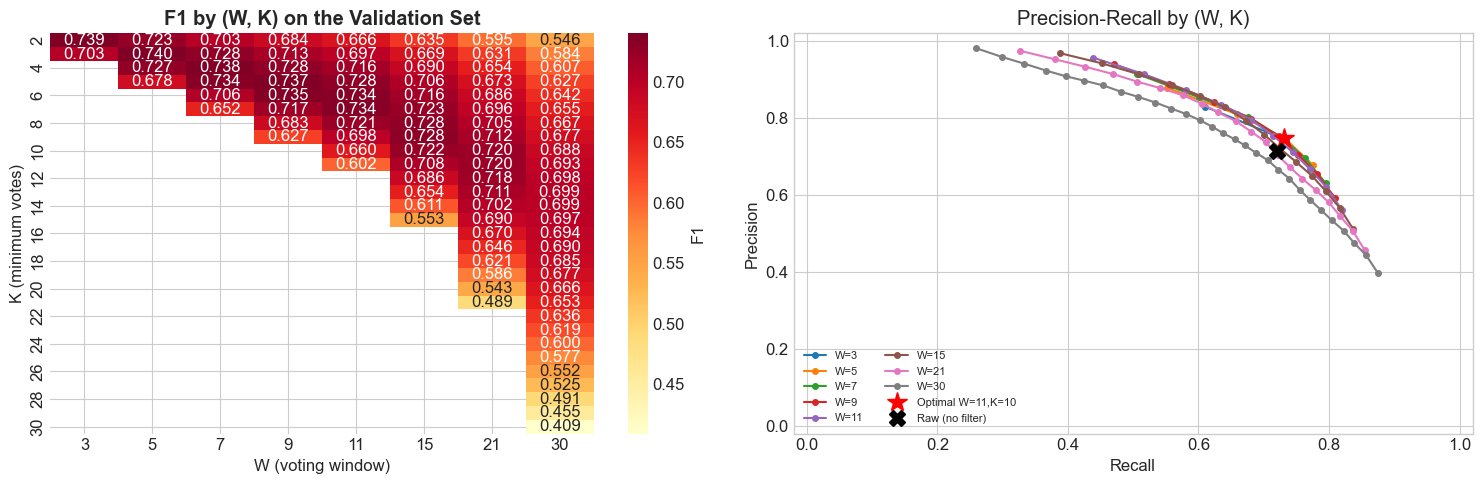

In [16]:
# Visualize the (W, K) grid search
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pivot = grid_df.pivot_table(index='K', columns='W', values='f1')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': 'F1'})
axes[0].set_title('F1 by (W, K) on the Validation Set', fontweight='bold')
axes[0].set_xlabel('W (voting window)')
axes[0].set_ylabel('K (minimum votes)')

ax = axes[1]
for W_val in W_candidates:
    sub = grid_df[grid_df['W'] == W_val]
    ax.plot(sub['recall'], sub['precision'], 'o-', label=f'W={W_val}', markersize=4)
ax.plot(best_row['recall'], best_row['precision'], '*', color='red',
        markersize=15, zorder=10, label=f'Optimal W={best_W},K={best_K}')
ax.plot(rc_raw_val, pr_raw_val, 'X', color='black',
        markersize=12, zorder=10, label='Raw (no filter)')
ax.set(xlabel='Recall', ylabel='Precision',
       title='Precision-Recall by (W, K)', xlim=(-0.02, 1.02), ylim=(-0.02, 1.02))
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

## 13. Smoothed Evaluation on Test

In [17]:
y_pred_raw    = (scores_test > best_thr).astype(int)
y_pred_smooth = temporal_vote_vectorized(y_pred_raw, best_W, best_K)

f1_s   = f1_score(y_test, y_pred_smooth)
f2_s   = fbeta_score(y_test, y_pred_smooth, beta=2)
prec_s = precision_score(y_test, y_pred_smooth)
rec_s  = recall_score(y_test, y_pred_smooth)

print('=' * 70)
print('COMPARISON - K-MEANS+IF: RAW vs TEMPORAL VOTING')
print('=' * 70)
print()
print(f'  {"Metric":12s} {"Raw":>10s} {"Smoothed":>10s} {"Delta":>10s}')
print('  ' + '-' * 45)
for name, raw_v, sm_v in [
    ('F1',        f1,   f1_s),
    ('F2',        f2,   f2_s),
    ('Precision',  prec,  prec_s),
    ('Recall',     rec,   rec_s),
]:
    delta = sm_v - raw_v
    print(f'  {name:12s} {raw_v:>10.4f} {sm_v:>10.4f} {delta:>+10.4f}')
print()
print(f'  Filter: W={best_W}, K={best_K} (causal voting)')
print(f'  Edge overhead: O(1)/sample, circular buffer of {best_W} integers')
print()
print(classification_report(y_test, y_pred_smooth,
                             target_names=['Normal', 'Attack']))

COMPARISON - K-MEANS+IF: RAW vs TEMPORAL VOTING

  Metric              Raw   Smoothed      Delta
  ---------------------------------------------
  F1               0.0001     0.7895    +0.7894
  F2               0.7586     0.7651    +0.0066
  Precision        0.7525     0.8337    +0.0813
  Recall           0.7601     0.7497    -0.0104

  Filter: W=11, K=10 (causal voting)
  Edge overhead: O(1)/sample, circular buffer of 11 integers

              precision    recall  f1-score   support

      Normal       0.95      0.97      0.96    508282
      Attack       0.83      0.75      0.79     96717

    accuracy                           0.94    604999
   macro avg       0.89      0.86      0.88    604999
weighted avg       0.93      0.94      0.93    604999



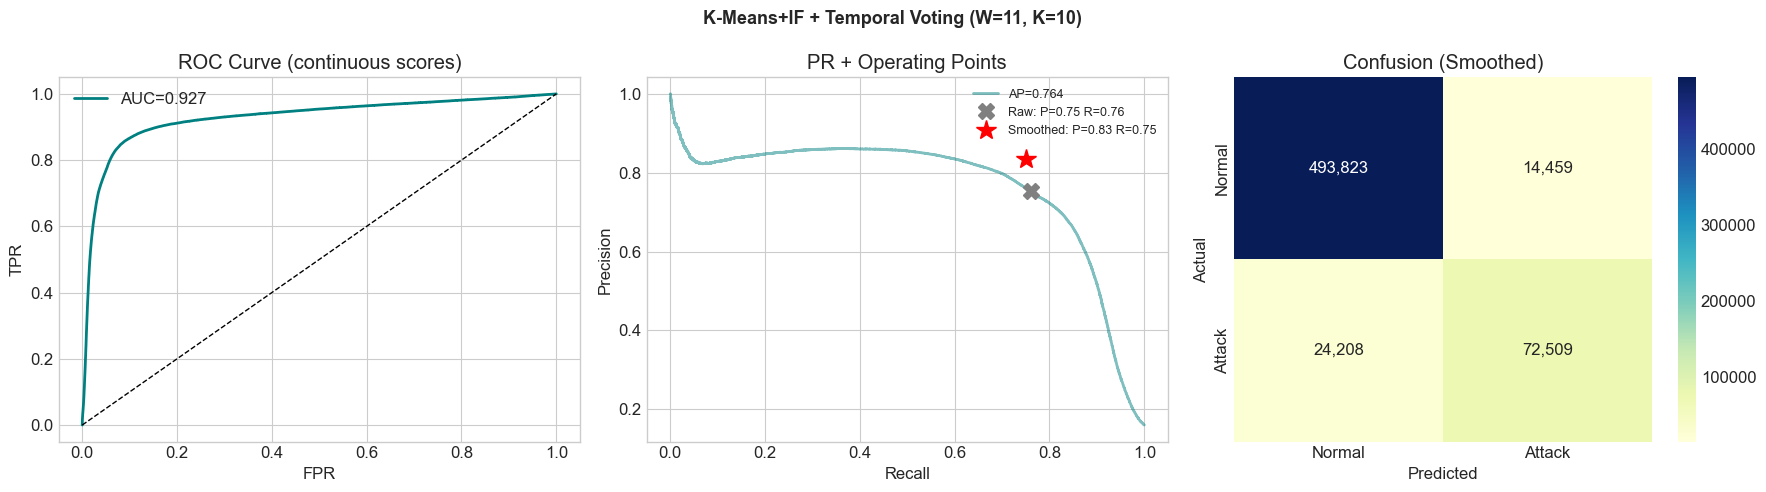

In [18]:
# ROC + PR + confusion matrix, smoothed predictions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr_s, tpr_s, _ = roc_curve(y_test, scores_test)
axes[0].plot(fpr_s, tpr_s, 'teal', lw=2, label=f'AUC={auc_roc:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve (continuous scores)')
axes[0].legend()

pr_c2, rc_c2, _ = precision_recall_curve(y_test, scores_test)
axes[1].plot(rc_c2, pr_c2, 'teal', lw=2, label=f'AP={auc_pr:.3f}', alpha=0.5)
axes[1].plot(rec, prec, 'X', color='gray', markersize=12,
             label=f'Raw: P={prec:.2f} R={rec:.2f}')
axes[1].plot(rec_s, prec_s, '*', color='red', markersize=15,
             label=f'Smoothed: P={prec_s:.2f} R={rec_s:.2f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='PR + Operating Points')
axes[1].legend(fontsize=9)

cm_s = confusion_matrix(y_test, y_pred_smooth)
sns.heatmap(cm_s, annot=True, fmt=',d', cmap='YlGnBu', ax=axes[2],
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'])
axes[2].set(xlabel='Predicted', ylabel='Actual', title='Confusion (Smoothed)')

plt.suptitle(f'K-Means+IF + Temporal Voting (W={best_W}, K={best_K})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

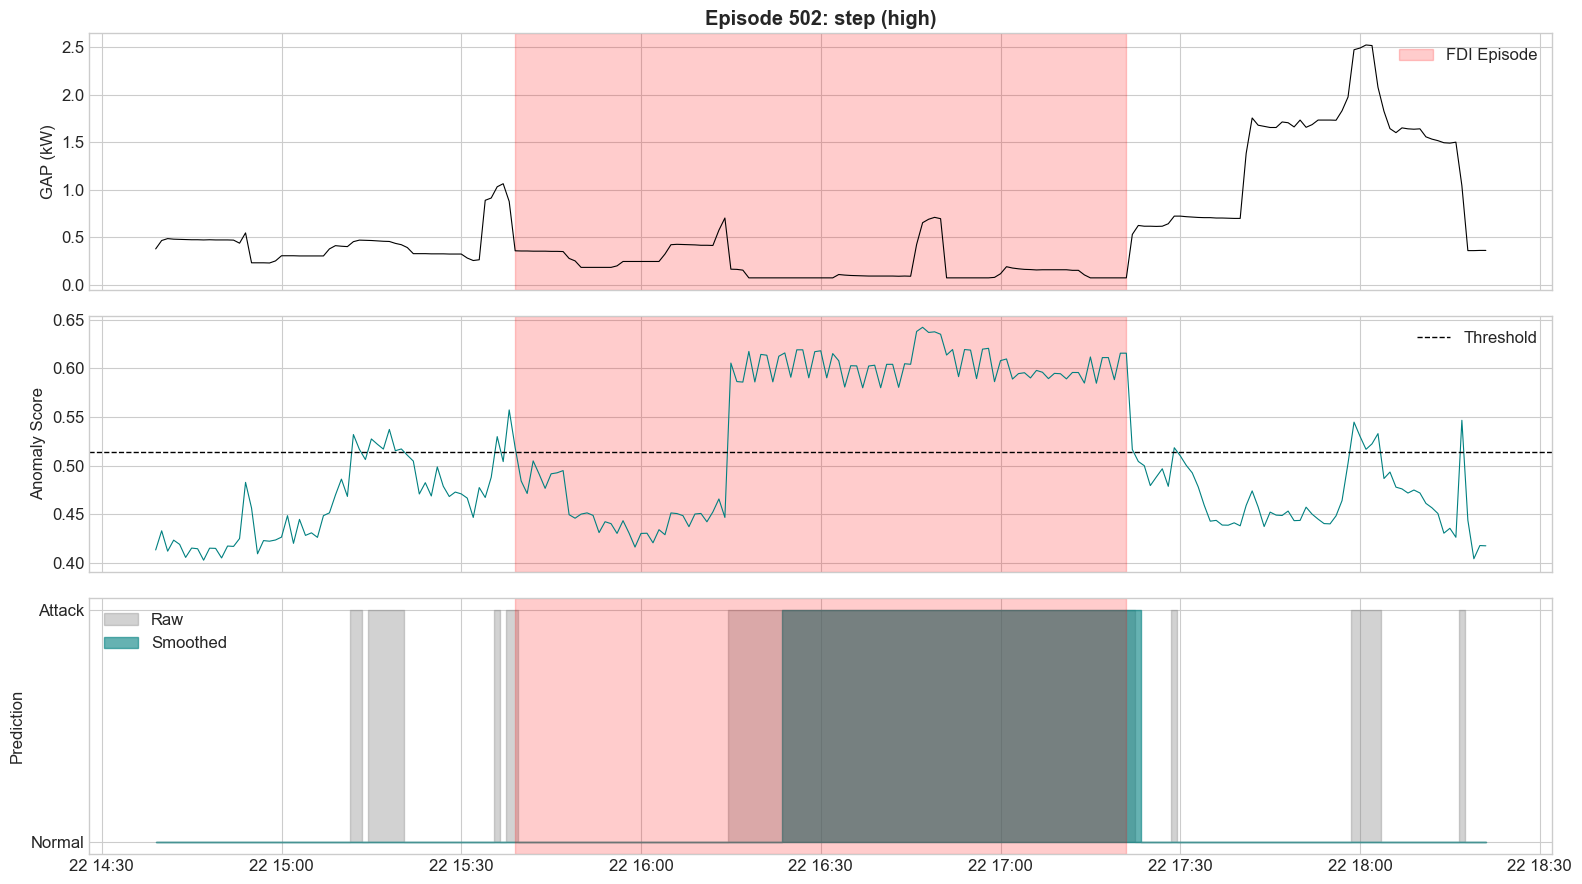

In [19]:
# Illustrate the filter's effect on one example episode
ep_ids = df_test.loc[df_test['episode_id'] >= 0, 'episode_id'].unique()
example_ep = None
for ep in ep_ids[:30]:
    mask = (df_test['episode_id'] == ep).values
    if y_pred_smooth[mask].any():
        example_ep = ep
        break

if example_ep is not None:
    mask = df_test['episode_id'] == example_ep
    ep_data = df_test[mask]
    ep_start = ep_data.index[0]
    ep_end   = ep_data.index[-1]

    ctx_start = ep_start - pd.Timedelta(minutes=60)
    ctx_end   = ep_end + pd.Timedelta(minutes=60)
    ctx = df_test.loc[ctx_start:ctx_end]

    fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

    axes[0].plot(ctx.index, ctx['Global_active_power'], 'k-', lw=0.8)
    axes[0].axvspan(ep_start, ep_end, alpha=0.2, color='red', label='FDI Episode')
    axes[0].set_ylabel('GAP (kW)')
    axes[0].set_title(f'Episode {example_ep}: {ep_data["attack_type"].iloc[0]} '
                       f'({ep_data["severity"].iloc[0]})', fontweight='bold')
    axes[0].legend()

    ctx_idx = df_test.index.get_indexer(ctx.index)
    valid = ctx_idx >= 0
    ctx_scores = scores_test[ctx_idx[valid]]
    axes[1].plot(ctx.index[valid], ctx_scores, 'teal', lw=0.8)
    axes[1].axhline(best_thr, color='k', linestyle='--', lw=1, label='Threshold')
    axes[1].axvspan(ep_start, ep_end, alpha=0.2, color='red')
    axes[1].set_ylabel('Anomaly Score')
    axes[1].legend()

    ctx_raw = y_pred_raw[ctx_idx[valid]]
    ctx_sm  = y_pred_smooth[ctx_idx[valid]]
    ctx_times = ctx.index[valid]
    axes[2].fill_between(ctx_times, 0, ctx_raw, alpha=0.35, color='gray',
                          step='mid', label='Raw')
    axes[2].fill_between(ctx_times, 0, ctx_sm, alpha=0.6, color='teal',
                          step='mid', label='Smoothed')
    axes[2].axvspan(ep_start, ep_end, alpha=0.2, color='red')
    axes[2].set_ylabel('Prediction')
    axes[2].set_yticks([0, 1])
    axes[2].set_yticklabels(['Normal', 'Attack'])
    axes[2].legend()

    plt.tight_layout()
    plt.show()
else:
    print('No suitable example episode found to visualize.')

## 14. Recall by Attack Type and Severity (Smoothed)

Recall by type x severity:
  Type                     N      Low      Med     High    Total
  -------------------------------------------------------
  scaling             13,449    0.564    0.900    0.904    0.802
  offset              13,898    0.825    0.911    0.926    0.892
  noise               14,357    0.625    0.864    0.889    0.799
  ramp                14,006    0.590    0.730    0.790    0.704
  step                13,731    0.562    0.573    0.551    0.563
  replay              14,084    0.502    0.684    0.755    0.651
  voltage_spoof       13,192    0.678    0.904    0.929    0.841


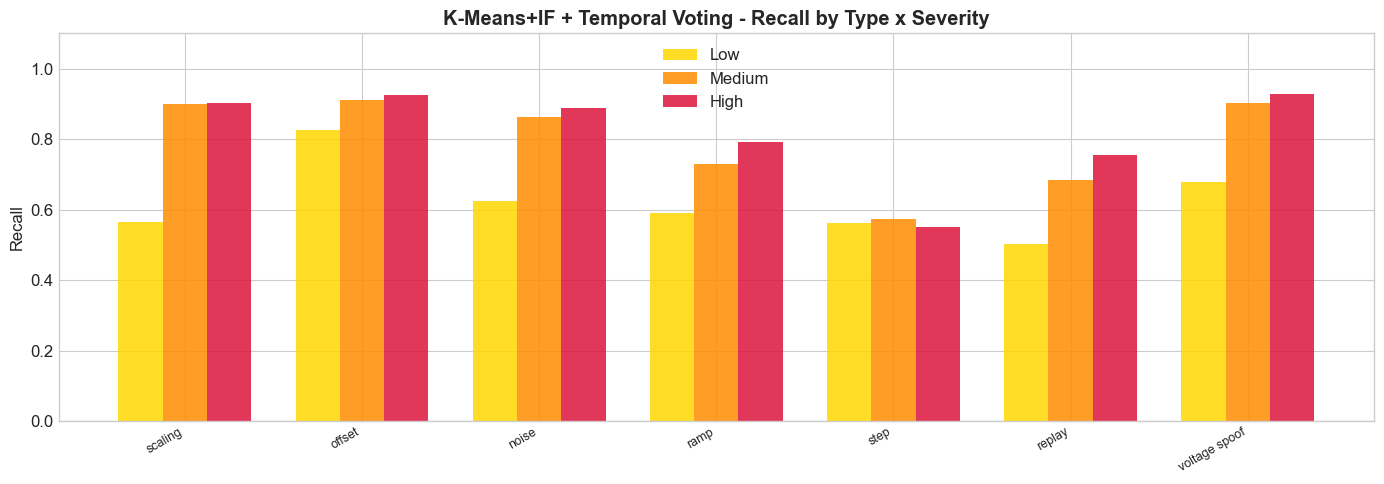

In [20]:
def recall_by_type_severity(attack_types_col, severity_col, y_true, y_pred,
                            attack_types_list, title_prefix):
    '''Print a table and bar plot of recall by attack type and severity.'''
    print(f'Recall by type x severity:')
    print(f'  {"Type":18s} {"N":>7s} {"Low":>8s} {"Med":>8s} {"High":>8s} {"Total":>8s}')
    print('  ' + '-' * 55)

    recall_data = {}
    for t in attack_types_list:
        mask_t = (attack_types_col == t)
        n_t = (mask_t & (y_true == 1)).sum()
        row = f'  {t:18s} {n_t:>7,}'
        for sev in ['low', 'medium', 'high']:
            mask = mask_t & (severity_col == sev) & (y_true == 1)
            n = mask.sum()
            if n > 0:
                r = (y_pred[mask] == 1).sum() / n
                row += f' {r:>8.3f}'
            else:
                r = np.nan
                row += f' {"---":>8s}'
            recall_data[(t, sev)] = r
        mask_all = mask_t & (y_true == 1)
        n_all = mask_all.sum()
        r_t = (y_pred[mask_all] == 1).sum() / n_all if n_all > 0 else 0
        row += f' {r_t:>8.3f}'
        print(row)

    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(len(attack_types_list))
    w = 0.25
    sev_colors = {'low': '#FFD700', 'medium': '#FF8C00', 'high': '#DC143C'}
    for i, (sev, c) in enumerate(sev_colors.items()):
        vals = []
        for t in attack_types_list:
            v = recall_data.get((t, sev), 0)
            vals.append(v if not (isinstance(v, float) and np.isnan(v)) else 0)
        ax.bar(x + i * w, vals, w, label=sev.capitalize(), color=c, alpha=0.85)
    ax.set_xticks(x + w)
    ax.set_xticklabels([t.replace('_', ' ') for t in attack_types_list],
                        rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Recall')
    ax.set_ylim(0, 1.1)
    ax.set_title(f'{title_prefix} - Recall by Type x Severity', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return recall_data


recall_data = recall_by_type_severity(
    attack_types_col=df_test['attack_type'].values,
    severity_col=df_test['severity'].values,
    y_true=y_test,
    y_pred=y_pred_smooth,
    attack_types_list=ATTACK_TYPES,
    title_prefix='K-Means+IF + Temporal Voting'
)

## 15. Detection Latency (Smoothed)

In [21]:
def compute_detection_latency(df_preds, score_col, threshold):
    '''Compute detection latency for each attack episode.'''
    results = []
    attacked = df_preds[df_preds['episode_id'] >= 0]
    for ep_id, group in attacked.groupby('episode_id'):
        group = group.sort_index()
        detections = group[group[score_col] > threshold]
        ep_start = group.index[0]
        results.append({
            'episode_id': ep_id,
            'type': group['attack_type'].iloc[0],
            'severity': group['severity'].iloc[0],
            'duration_min': len(group),
            'latency_min': (
                (detections.index[0] - ep_start).total_seconds() / 60
                if len(detections) > 0 else np.nan
            ),
            'detected': len(detections) > 0
        })
    return pd.DataFrame(results)


def print_latency_summary(lat_df):
    '''Summarize detection rate and latency, broken down by severity.'''
    det_rate = lat_df['detected'].mean()
    detected = lat_df[lat_df['detected']]
    med_lat  = detected['latency_min'].median() if len(detected) > 0 else np.nan

    print(f'Detection per episode: {det_rate:.1%} ({lat_df["detected"].sum()}/{len(lat_df)})')
    if not np.isnan(med_lat):
        print(f'Median latency:        {med_lat:.1f} min')
    print()

    for sev in ['low', 'medium', 'high']:
        sub = lat_df[lat_df['severity'] == sev]
        if len(sub) == 0:
            continue
        det = sub['detected'].mean()
        det_sub = sub[sub['detected']]
        lat = det_sub['latency_min'].median() if len(det_sub) > 0 else np.nan
        lat_s = f'{lat:.1f} min' if not np.isnan(lat) else 'N/A'
        print(f'  {sev:8s}: detection {det:.0%}  |  median latency {lat_s}')

    return det_rate, med_lat


df_test_scored = df_test.copy()
df_test_scored['kmif_pred_smooth'] = y_pred_smooth.astype(float)

lat_df = compute_detection_latency(df_test_scored, 'kmif_pred_smooth', 0.5)
det_rate, med_lat = print_latency_summary(lat_df)

print()
print(f'NOTE: The voting filter adds latency of up to {best_W-1} min')
print(f'      with respect to raw (it needs to accumulate {best_K} votes of {best_W}).')

Detection per episode: 98.2% (825/840)
Median latency:        9.0 min

  low     : detection 95%  |  median latency 15.0 min
  medium  : detection 100%  |  median latency 9.0 min
  high    : detection 100%  |  median latency 9.0 min

NOTE: The voting filter adds latency of up to 10 min
      with respect to raw (it needs to accumulate 10 votes of 11).


## 16. Comparison with the IF Baseline (NB03)

We load `metrics_isolation_forest.json`, generated by NB03, to compare both models
directly under identical conditions.

In [22]:
nb03_path = os.path.join(DATA_DIR, 'metrics_isolation_forest.json')

if os.path.exists(nb03_path):
    with open(nb03_path) as f:
        m03 = json.load(f)

    print('=' * 75)
    print('FINAL COMPARISON: IF baseline (NB03)  vs  K-Means+IF (NB03b)')
    print('=' * 75)
    print()

    comparisons = [
        ('F1 (smoothed)',    m03.get('f1', 0),        f1_s),
        ('F2 (smoothed)',    m03.get('f2', 0),        f2_s),
        ('Precision (sm.)',  m03.get('precision', 0),  prec_s),
        ('Recall (sm.)',     m03.get('recall', 0),     rec_s),
        ('AUC-ROC',         m03.get('auc_roc', 0),    auc_roc),
        ('AUC-PR',          m03.get('auc_pr', 0),     auc_pr),
        ('Raw F1',          m03.get('raw_f1', 0),     f1),
        ('Raw Precision',   m03.get('raw_precision', 0), prec),
        ('Raw Recall',      m03.get('raw_recall', 0), rec),
    ]

    print(f'  {"Metric":20s} {"IF (NB03)":>12s} {"K-Means+IF":>12s} {"Delta":>12s}')
    print('  ' + '-' * 60)
    for name, v_old, v_new in comparisons:
        delta = v_new - v_old
        arrow = '+' if delta > 0.0005 else ('-' if delta < -0.0005 else '=')
        print(f'  {name:20s} {v_old:>12.4f} {v_new:>12.4f} {delta:>+11.4f} {arrow}')

    print()
    print(f'  {"Edge":20s} {"IF (NB03)":>12s} {"K-Means+IF":>12s}')
    print('  ' + '-' * 46)
    size_nb03 = m03.get("model_size_kb", "?")
    ms_nb03 = m03.get("ms_per_sample", "?")
    nf_nb03 = m03.get("n_features", "?")
    print(f'  {"Features":20s} {str(nf_nb03):>12s}   (computed in S17)')
    print(f'  {"ms/sample":20s} {str(ms_nb03):>12s}   (computed in S17)')
    print(f'  {"Temporal (W,K)":20s}  ({m03.get("temporal_W","?")},{m03.get("temporal_K","?")})         ({best_W},{best_K})')

else:
    print('metrics_isolation_forest.json not found.')
    print('Run NB03 first to generate the baseline metrics.')
    print()
    print('K-Means+IF metrics (this notebook):')
    print(f'  F1={f1_s:.4f}  F2={f2_s:.4f}  P={prec_s:.4f}  R={rec_s:.4f}')
    print(f'  AUC-ROC={auc_roc:.4f}  AUC-PR={auc_pr:.4f}')

FINAL COMPARISON: IF baseline (NB03)  vs  K-Means+IF (NB03b)

  Metric                  IF (NB03)   K-Means+IF        Delta
  ------------------------------------------------------------
  F1 (smoothed)              0.7544       0.7895     +0.0351 +
  F2 (smoothed)              0.7499       0.7651     +0.0152 +
  Precision (sm.)            0.7621       0.8337     +0.0716 +
  Recall (sm.)               0.7469       0.7497     +0.0028 +
  AUC-ROC                    0.9266       0.9270     +0.0004 =
  AUC-PR                     0.7824       0.7644     -0.0180 -
  Raw F1                     0.0001       0.0001     -0.0000 =
  Raw Precision              0.7517       0.7525     +0.0008 +
  Raw Recall                 0.7413       0.7601     +0.0188 +

  Edge                    IF (NB03)   K-Means+IF
  ----------------------------------------------
  Features                       17   (computed in S17)
  ms/sample                  0.0095   (computed in S17)
  Temporal (W,K)        (3,2)      

## 17. Edge Computing and Saving

In [23]:
# Persist the model bundle (K-Means + the winning IF strategy)
save_bundle = {
    'strategy': STRATEGY,
    'n_clusters': BEST_K,
    'kmeans': kmeans,
}
if STRATEGY == 'B':
    save_bundle['isolation_forest'] = model_if_B
else:
    save_bundle['isolation_forests'] = models_per_cluster

model_path = os.path.join(DATA_DIR, 'model_kmeans_if.pkl')
joblib.dump(save_bundle, model_path)
size_kb = os.path.getsize(model_path) / 1e3

joblib.dump(scaler, os.path.join(DATA_DIR, 'scaler_kmeans_if.pkl'))

# End-to-end timing: K-Means predict + IF score (the full inference pipeline)
if STRATEGY == 'B':
    _ = model_if_B.score_samples(X_test_aug[:100])  # warm up caches before timing
    times = []
    for _ in range(5):
        t0 = time.time()
        _cl = kmeans.predict(X_test)
        _X_aug = add_cluster_onehot(X_test, _cl, BEST_K)
        model_if_B.score_samples(_X_aug)
        times.append(time.time() - t0)
else:
    times = []
    for _ in range(5):
        t0 = time.time()
        _cl = kmeans.predict(X_test)
        score_per_cluster(X_test, _cl, models_per_cluster)
        times.append(time.time() - t0)

ms_avg = np.mean(times) / len(X_test) * 1000

print('=' * 60)
print('EDGE COMPUTING - K-MEANS+IF + TEMPORAL VOTING')
print('=' * 60)
strat_desc = 'global IF + cluster feat.' if STRATEGY == 'B' else f'{BEST_K} IFs per cluster'
n_feat = len(feat_names_aug) if STRATEGY == 'B' else len(feat_names)
print(f'  Strategy:         {STRATEGY} ({strat_desc})')
print(f'  Clusters:         {BEST_K}')
print(f'  Features:         {n_feat}')
print(f'  Temporal filter:  W={best_W}, K={best_K} (buffer {best_W} integers)')
print(f'  Size on disk:     {size_kb:.1f} KB')
print(f'  Latency:          {ms_avg:.4f} ms/sample (KMeans + IF + filter)')
print(f'  Throughput:       {1000/ms_avg:,.0f} samples/s')
print(f'  Granularity:      1 minute (real time)')
print(f'  Training:         {t_train:.1f} s')

# Save per-minute predictions
df_out = df_test.copy()
df_out['kmif_score']       = scores_test
df_out['kmif_pred_raw']    = y_pred_raw
df_out['kmif_pred_smooth'] = y_pred_smooth
df_out['cluster']          = cluster_test
df_out.to_csv(os.path.join(DATA_DIR, 'predictions_kmeans_if.csv'))
lat_df.to_csv(os.path.join(DATA_DIR, 'latency_kmeans_if.csv'), index=False)

# Save the metrics JSON
metrics = {
    'model': f'K-Means(K={BEST_K}) + IF + Temporal Voting (Strategy {STRATEGY})',
    'feature_mode': 'full + cluster_onehot' if STRATEGY == 'B' else 'full (per-cluster)',
    'raw_f1': round(f1, 4), 'raw_f2': round(f2, 4),
    'raw_precision': round(prec, 4), 'raw_recall': round(rec, 4),
    'f1': round(f1_s, 4), 'f2': round(f2_s, 4),
    'precision': round(prec_s, 4), 'recall': round(rec_s, 4),
    'auc_roc': round(auc_roc, 4), 'auc_pr': round(auc_pr, 4),
    'threshold': round(float(best_thr), 6),
    'temporal_W': best_W, 'temporal_K': best_K,
    'n_clusters': BEST_K, 'strategy': STRATEGY,
    'silhouette_scores': {str(k): round(s, 4) for k, s in zip(K_range, silhouettes)},
    'scaler_ablation': ablation_results,
    'model_size_kb': round(size_kb, 1),
    'ms_per_sample': round(ms_avg, 4),
    'n_features': n_feat,
    'train_time_s': round(t_train, 2),
    'detection_rate': round(det_rate, 4),
    'median_latency_min': round(float(med_lat), 1) if not np.isnan(med_lat) else None,
    'granularity': '1 min',
    'feature_names': feat_names_aug if STRATEGY == 'B' else feat_names,
}

with open(os.path.join(DATA_DIR, 'metrics_kmeans_if.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

print()
print('Saved in data/:')
for fn in ['predictions_kmeans_if.csv', 'metrics_kmeans_if.json',
           'model_kmeans_if.pkl', 'scaler_kmeans_if.pkl',
           'latency_kmeans_if.csv']:
    print(f'  * {fn}')

EDGE COMPUTING - K-MEANS+IF + TEMPORAL VOTING
  Strategy:         A (3 IFs per cluster)
  Clusters:         3
  Features:         17
  Temporal filter:  W=11, K=10 (buffer 11 integers)
  Size on disk:     17425.4 KB
  Latency:          0.0114 ms/sample (KMeans + IF + filter)
  Throughput:       87,366 samples/s
  Granularity:      1 minute (real time)
  Training:         10.2 s

Saved in data/:
  * predictions_kmeans_if.csv
  * metrics_kmeans_if.json
  * model_kmeans_if.pkl
  * scaler_kmeans_if.pkl
  * latency_kmeans_if.csv


## 18. Summary

### K-Means + IF vs the IF Baseline

| Aspect | IF alone (NB03) | K-Means + IF (NB03b) |
|---|---|---|
| Context | None | Consumption regime via the cluster id |
| Features | 17 (full) | 17 + K one-hot |
| Hypothesis | "every anomaly looks the same" | "what counts as anomalous depends on the hourly context" |
| Normalization | RobustScaler (unjustified) | RobustScaler (**validated** by ablation) |
| Edge overhead | IF score | K-Means predict (~us) + IF score |

### Interpretation

- If K-Means + IF **improves F1**, the regime context reduces false positives caused by
  confusion between consumption patterns (early morning vs peak), which validates the
  hypothesis.

- If K-Means + IF **does not improve F1**, the cyclical features (hour_sin/cos, dow_sin/cos)
  already capture enough temporality and K-Means is redundant. **This conclusion is just
  as valuable for the TFG.**

### From a deployment standpoint

- The K-Means -> IF pipeline is **interpretable**: "your plant has N consumption regimes,
  and this anomaly occurred during the nighttime regime, where consumption should be X."
- The K-Means predict step adds **negligible** overhead on edge (~1 us per centroid).
- It is an ideal model for **deployment on an ESP32/RPi**: small footprint, low latency.

### Generated files

| File | Content |
|---|---|
| `predictions_kmeans_if.csv` | Scores + raw/smoothed predictions + cluster id per minute |
| `metrics_kmeans_if.json` | Full metrics + ablation + silhouette scores |
| `model_kmeans_if.pkl` | Bundle: K-Means + IF (winning strategy) |
| `scaler_kmeans_if.pkl` | Fitted RobustScaler |
| `latency_kmeans_if.csv` | Detection latency per episode |